In [33]:
import csv
import pandas as pd
from sklearn.cluster import KMeans
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt

Get most common tags and replace the list of tags for each element with the most common tag

In [14]:
# Read the CSV file and extract the tags column
with open('medium_articles.csv', 'r',encoding="utf8") as file:
    reader = csv.DictReader(file)
    tags = [row['tags'] for row in reader]

# Convert each tags list to a Counter object and get the most common tag
most_common_tags = [Counter(eval(tag)).most_common(1)[0][0] for tag in tags]

# Replace the tags column in the original CSV file with the most common tag
with open('medium_articles.csv', 'r',encoding="utf8") as file:
    reader = csv.reader(file)
    headers = next(reader)
    rows = [[*row[:headers.index('tags')], most_common_tags[i], *row[headers.index('tags')+1:]] for i, row in enumerate(reader)]
    
with open('medium_articles_nolist.csv', 'w',encoding="utf8", newline='') as file:
    writer = csv.writer(file)
    writer.writerow(headers)
    writer.writerows(rows)

In [43]:
most_common_tags[:50]

['Mental Health',
 'Mental Health',
 'Biotechnology',
 'Health',
 'Brain',
 'Society',
 'Books',
 'People',
 'Self Improvement',
 'Machine Learning',
 'Entrepreneurship',
 'Productivity',
 'Health',
 'Writing',
 'Productivity',
 'Lifestyle',
 'Work',
 'New York',
 'Suicide',
 'Marketing',
 'Marketing',
 'Health',
 'Creativity',
 'Humor',
 'Entrepreneurship',
 'Neuroscience',
 'Marketing',
 'Marketing',
 'Books',
 'Exploratory Data Analysis',
 'Apple',
 'Life Lessons',
 'Productivity',
 'Creativity',
 'AI',
 'Neuroscience',
 'Economy',
 'Marketing',
 'Social Media',
 'Productivity',
 'Writing',
 'Self Improvement',
 'Machine Learning',
 'Creativity',
 'Marketing',
 'Society',
 'Neuroscience',
 'Social Media',
 'Writing',
 'Leadership']

do this step for tags
1. Take the 6 tags that you want.
2. Select all the records from the dataset which has these tags -> training data
3. The rest will be the prediction data
4. Run tf-idf both and X is list of tags and Y is the tag I want to predict
5. Train a Naive Bayes on the training set
6. Run the Naive Bayes on whole dataset to get the 6 cetagories that you want.

after 

Now we want to cluster the tags and assign each tag of element to the main cluster

naive bayes input = text output = category:
machine learning

1. Take the 6 tags that you want.
2. Select all the records from the dataset which has these tags -> training data
3. The rest will be the prediction data
4. Remove stopwords, run porter/stemmer, run tf-idf on training text. Leave training TAG as target variable
5. Train a Naive Bayes on the training set
6. Run the Naive Bayes on the testing set and the training set to get the 6 cetagories that you want.

In [39]:
# Load the dataset
data = pd.read_csv('medium_articles_nolist.csv')

# Extract the unique tags
tags = set(data['tags'])
tags = [tag for tag in tags if isinstance(tag, str)]

In [41]:
data['tags']

0         Mental Health
1         Mental Health
2         Biotechnology
3                Health
4                 Brain
              ...      
192363         Cleaning
192364          Bedding
192365         Cleaning
192366          Romania
192367        Hong Kong
Name: tags, Length: 192368, dtype: object

Vectorize the tags. using TfidfVectorizer from scikit-learn to convert the tags into numerical vectors.

In [18]:
# Vectorize the tags
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(tags)

In [24]:
print(X)

  (0, 9201)	1.0
  (1, 2150)	1.0
  (2, 16735)	1.0
  (3, 3221)	1.0
  (4, 5858)	1.0
  (5, 18852)	1.0
  (6, 4388)	0.5521859233242832
  (6, 12454)	0.8337210001448379
  (7, 15882)	1.0
  (8, 10965)	1.0
  (9, 14741)	0.8295744907401162
  (9, 15480)	0.5583960640202229
  (10, 12305)	0.6931475612267107
  (10, 6034)	0.7207957119499694
  (11, 2865)	0.7328657057971433
  (11, 10764)	0.6803733219832
  (12, 15521)	1.0
  (13, 3014)	1.0
  (14, 4263)	1.0
  (15, 6006)	0.7071067811865475
  (15, 6057)	0.7071067811865475
  (16, 17378)	0.6679711292489011
  (16, 10242)	0.7441871878028725
  (17, 3482)	1.0
  (18, 16340)	0.7264234800777317
  :	:
  (28659, 14987)	0.5899169780650431
  (28660, 13716)	1.0
  (28661, 1529)	0.6504738422366179
  (28661, 16014)	0.6255230849921805
  (28661, 1966)	0.43081858212918006
  (28662, 3536)	1.0
  (28663, 12447)	1.0
  (28664, 1204)	0.6167466751164404
  (28664, 10852)	0.5746915257927757
  (28664, 22)	0.537915596459879
  (28665, 550)	1.0
  (28666, 3461)	0.774818149629885
  (28666, 14047

Apply clustering to group the tags into 6 clusters using kmeans

methodology to determine the number of clusters

c:\Users\223079929\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


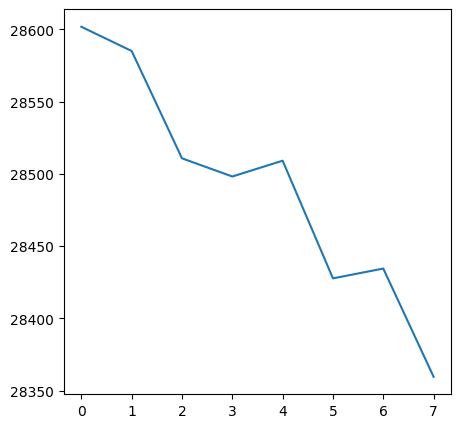

In [34]:
# Apply KMeans clustering
kmeans_objs = [KMeans(n_clusters=i).fit(X).inertia_ for i in range(2,10)]
# kmeans = KMeans(n_clusters=6)
# kmeans.fit(X)
# print(kmeans.cluster_centers_)

plt.figure(figsize=(5,5))
plt.plot(kmeans_objs)
plt.show()

c:\Users\223079929\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\223079929\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\223079929\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\223079929\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4

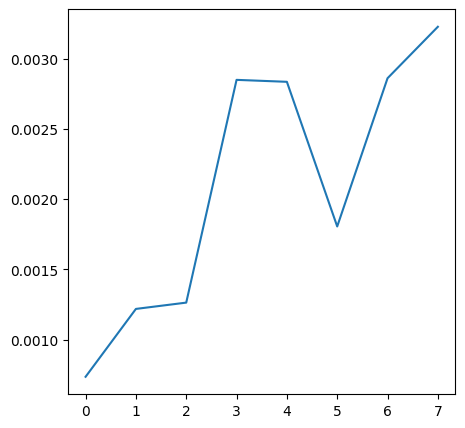

In [37]:
from sklearn.metrics import silhouette_score
# Apply KMeans clustering
kmeans_objs = [silhouette_score(X, KMeans(n_clusters=i).fit(X).labels_) for i in range(2,10)]

plt.figure(figsize=(5,5))
plt.plot(kmeans_objs)
plt.show()

take ceter of cluster and take the closest tag as a name of this cluster
k means. cluster _ centers

Assign each tag to its cluster and create a dictionary to map each tag to its main tag.

In [26]:
# Assign each tag to its cluster
clusters = kmeans.labels_

# Create a dictionary to map each tag to its main tag
tag_to_main = {}
for i, tag in enumerate(tags):
    tag_to_main[tag] = f"Main Tag {clusters[i]+1}"

Update the dataset with the main tags. apply the tag_to_main dictionary to the tags column in dataset and create a new column with the main tags.

In [27]:
# Update the dataset with the main tags
data['main_tags'] = data['tags'].apply(lambda x: tag_to_main.get(x, 'unknown') if pd.notnull(x) else 'unknown')
# remove 'unknown' main tag and save the updated dataset to a new csv file
data = data[data['main_tags'] != 'unknown']
data.to_csv('medium_articles_nolist_6tags.csv', index=False)

porter stemmer tags

In [29]:
df2 = pd.read_csv("medium_articles_nolist_6tags.csv")
df2[1:20]

,title,text,url,authors,timestamp,tags,main_tags
1,Your Brain On Coronavirus,Your Brain On Coronavirus\n\nA guide to the cu...,https://medium.com/age-of-awareness/how-the-pa...,['Simon Spichak'],2020-09-23 22:10:17.126000+00:00,Mental Health,Main Tag 2
2,Mind Your Nose,Mind Your Nose\n\nHow smell training can chang...,https://medium.com/neodotlife/mind-your-nose-f...,[],2020-10-10 20:17:37.132000+00:00,Biotechnology,Main Tag 2
3,The 4 Purposes of Dreams,Passionate about the synergy between science a...,https://medium.com/science-for-real/the-4-purp...,['Eshan Samaranayake'],2020-12-21 16:05:19.524000+00:00,Health,Main Tag 2
4,Surviving a Rod Through the Head,"You’ve heard of him, haven’t you? Phineas Gage...",https://medium.com/live-your-life-on-purpose/s...,['Rishav Sinha'],2020-02-26 00:01:01.576000+00:00,Brain,Main Tag 2
5,"Mentally, Young Adults Are Suffering Most From...","Mentally, Young Adults Are Suffering Most From...",https://medium.com/the-partnered-pen/mentally-...,['Ryan Fan'],2020-11-19 15:27:36.001000+00:00,Society,Main Tag 2
6,How to Turn Your Popular Blog Series Into a Be...,How to Turn Your Popular Blog Series Into a Be...,https://frankmckinley.medium.com/want-to-turn-...,['Frank Mckinley'],2020-01-28 03:36:58.566000+00:00,Books,Main Tag 2
7,Dr Faisal Dar — Pioneer of Liver Transplantati...,Dr Faisal Dar — Pioneer of Liver Transplantati...,https://medium.com/storyfest/dr-faisal-dar-pio...,['Fatima Arif'],2019-02-28 06:01:04.914000+00:00,People,Main Tag 2
8,Sunlight — The Natural Supplement For Our Ment...,Sunlight — The Natural Supplement For Our Ment...,https://medium.com/wholistique/sunlight-the-na...,['Jerren Gan'],2020-12-16 10:47:37.171000+00:00,Self Improvement,Main Tag 2
9,Occam’s dice,Occam’s dice\n\nDistrusting biological metapho...,https://medium.com/the-spike/occams-dice-258aa...,['Kelly Clancy'],2018-08-22 14:55:56.262000+00:00,Machine Learning,Main Tag 2
10,"To Quickly Build Trust, Tell Your Origin Story",Photo credit: Leo Leung\n\nPeople want to know...,https://medium.com/the-mission/want-trust-shar...,['Andy Raskin'],2016-07-06 19:45:00.648000+00:00,Entrepreneurship,Main Tag 2


In [15]:
# Read in the CSV file as a Pandas DataFrame
df = pd.read_csv('medium_articles_nolist_6tags.csv')

# Group the rows by the values in the 'main_tags' column and collect all the tags assigned to each group
tag_groups = df.groupby('main_tags')['tags'].apply(list)

# Loop over the groups and get the most common tag for each group
for group, tags in tag_groups.items():
    tag_counts = Counter(tags)
    top_tag, count = tag_counts.most_common(1)[0]
    print(f"Most common tag for {group}: {top_tag} (count={count})")

Most common tag for Main Tag 1: Money (count=483)
Most common tag for Main Tag 2: Scholarx (count=1)
Most common tag for Main Tag 3: The Daily Pick (count=78)
Most common tag for Main Tag 4: Machine Learning (count=2178)
Most common tag for Main Tag 5: Design (count=595)
Most common tag for Main Tag 6: Guns (count=34)


Remove unecessary columns, switch places remained ones and rename them

In [23]:
# Remove column
data = pd.read_csv('medium_articles_nolist_6tags.csv')
columns_to_remove = ['title', 'url', 'authors', 'timestamp', 'tags']
data = data.drop(columns_to_remove, axis=1)

# Switch columns places
col1 = data['text']
col2 = data['main_tags']
data['text'] = col2
data['main_tags'] = col1

# Rename columns
data = data.rename(columns={'text': 'category', 'main_tags': 'text'})

# Save modified DataFrame to new CSV file
data.to_csv('medium_articles_nolist_6tags_cleared.csv', index=False)

Rename column to its appropriate name from bbc dataset

In [24]:
data = pd.read_csv('medium_articles_nolist_6tags_cleared.csv')
for index, row in data.iterrows():
    if row['category'] == 'Main Tag 5':
        data.iloc[index, 0] = 'marketing'
    if row['category'] == 'Main Tag 4':
        data.iloc[index, 0] = 'tech'
    if row['category'] == 'Main Tag 1':
        data.iloc[index, 0] = 'business'

remove unecessary elements

In [25]:
data = data[data['category'] != 'Main Tag 2']
data = data[data['category'] != 'Main Tag 3']
data = data[data['category'] != 'Main Tag 6']

categories = set(data['category'])
categories
data.to_csv('medium_articles_nolist_6tags_cleared.csv', index=False)

load bbc dataset and rename certain category

In [26]:
data = pd.read_csv('bbc-text.csv')
for index, row in data.iterrows():
    if row['category'] == 'entertainment':
        data.iloc[index, 0] = 'marketing'

In [27]:
categories = set(data['category'])
categories

{'business', 'marketing', 'politics', 'sport', 'tech'}

combine together meium and bbc datasets into one which will be the final dataset for NLP algorithms

In [4]:
# Load the first CSV file into a DataFrame
df1 = pd.read_csv('medium_articles_nolist_6tags_cleared.csv')

# Load the second CSV file into a DataFrame
df2 = pd.read_csv('bbc-text.csv')

# Combine the two DataFrames into a single DataFrame
result = pd.concat([df1, df2])

# Save the combined DataFrame to a new CSV file
result.to_csv('medium_and_bbc.csv', index=False)

In [3]:
data = pd.read_csv('medium_and_bbc.csv')
categories = set(data['category'])
categories

{'business', 'entertainment', 'marketing', 'politics', 'sport', 'tech'}

In [5]:
data[1:4]

,category,text
1,tech,Your Brain On Coronavirus\n\nA guide to the cu...
2,tech,Mind Your Nose\n\nHow smell training can chang...
3,tech,Passionate about the synergy between science a...


In [6]:

category_counts = {}

# Open the CSV file and read the data
with open('medium_and_bbc.csv', 'r', encoding='utf-8') as csv_file:
    reader = csv.DictReader(csv_file)
    for row in reader:
        # Get the category of the current row
        category = row['category']
        
        # Update the count for the current category in the dictionary
        if category in category_counts:
            category_counts[category] += 1
        else:
            category_counts[category] = 1

# Print the category counts
for category, count in category_counts.items():
    print(f'{category}: {count}')


tech: 188506
marketing: 2449
business: 1799
sport: 511
entertainment: 386
politics: 417


In [6]:
df = pd.read_csv("medium_articles.csv")
df[1:4]

,title,text,url,authors,timestamp,tags
1,Your Brain On Coronavirus,Your Brain On Coronavirus\n\nA guide to the cu...,https://medium.com/age-of-awareness/how-the-pa...,['Simon Spichak'],2020-09-23 22:10:17.126000+00:00,"['Mental Health', 'Coronavirus', 'Science', 'P..."
2,Mind Your Nose,Mind Your Nose\n\nHow smell training can chang...,https://medium.com/neodotlife/mind-your-nose-f...,[],2020-10-10 20:17:37.132000+00:00,"['Biotechnology', 'Neuroscience', 'Brain', 'We..."
3,The 4 Purposes of Dreams,Passionate about the synergy between science a...,https://medium.com/science-for-real/the-4-purp...,['Eshan Samaranayake'],2020-12-21 16:05:19.524000+00:00,"['Health', 'Neuroscience', 'Mental Health', 'P..."


In [11]:
[x for x in df['tags']]

["['Mental Health', 'Health', 'Psychology', 'Science', 'Neuroscience']",
 "['Mental Health', 'Coronavirus', 'Science', 'Psychology', 'Neuroscience']",
 "['Biotechnology', 'Neuroscience', 'Brain', 'Wellness', 'Science']",
 "['Health', 'Neuroscience', 'Mental Health', 'Psychology', 'Science']",
 "['Brain', 'Health', 'Development', 'Psychology', 'Science']",
 "['Society', 'Mental Health', 'Health', 'Nonfiction', 'Coronavirus']",
 "['Books', 'Entrepreneurship', 'Writing', 'Marketing', 'Productivity']",
 "['People', 'Storyfest', 'Health', 'Pakistan', 'Storytelling']",
 "['Self Improvement', 'Mental Health', 'Health', 'Wellness', 'Science']",
 "['Machine Learning', 'Science', 'Neuroscience', 'Psychology', 'Artificial Intelligence']",
 "['Entrepreneurship', 'Personal Development', 'Startup', 'Marketing', 'Storytelling']",
 "['Productivity', 'Writing', 'Fiction', 'Books', 'Creativity']",
 "['Health', 'Science', 'Wellness', 'Coronavirus', 'Covid 19']",
 "['Writing', 'Psychology', 'Interior Desi